## 1. Import Necessary libraries

In [47]:
import pandas as pd #To read files
from matplotlib import pyplot as plt # Used for graph data visualization 
import seaborn as sns # Data Visualization Library
from sklearn.linear_model import LinearRegression # supports LinearRegression.You can then create a model, fit it on data, and make predictions.
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore") # to ignore warnings

## 2. Import Dataset

In [3]:
cars_data = pd.read_csv(filepath_or_buffer = "Cars.csv")
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


## 3. Data Understanding

### 3.1 perform Initial Investigation on the data

In [4]:
cars_data.shape

(81, 5)

In [5]:
cars_data.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [6]:
cars_data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

In [7]:

cars_data.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


## Now, let's check for the Assumptions (mpg is output and other features are input)

| Assumption           | How to Check                      |
| -------------------- | --------------------------------- |
| Linearity            | Scatter Plot / lmplot             |
| Normality            | Histogram,histplot,Q-Q Plot, Shapiro Test |
| No Autocorrelation(Independence)       | Durbin-Watson Test                |
| Homoscedasticity     | Residual Plot                     |
| No Multicollinearity | Correlation Matrix,heatmap,data_set.corr(),Variance Inflation Factor        |
| Zero Mean Residuals  | Mean of residuals ≈ 0             |


Before Model Building Data level Linearity test and No Multicollinearity can be done. residuals means errors.
after model building other tests can be done because you want to test on errors (actual value - predications)

## Test 1: Data Level Linearity Test (relationship  between input and output is represented by a straight line)
- Purpose: Check whether the relationship between the independent variable (input, X) and dependent variable (output, Y) can be represented by a straight line.

- Key Points
- The relationship between X and Y should be approximately linear.

- Use a scatter plot to visualize the data.

- A regression line (e.g., using an lmplot in Seaborn) can help show the trend.

- If the data points are clustered around the straight line with no obvious curve or pattern, the linearity assumption is likely satisfied.

- If the points show a curved pattern or are widely scattered away from the line, the linearity assumption may be violated.

  
Interpretation

- ✅ Linearity Passed: Most points lie close to the regression line, and the overall pattern looks straight.

- ❌ Linearity Failed: The points form a curve, wave, or other non-linear pattern instead of following a straight-line trend.

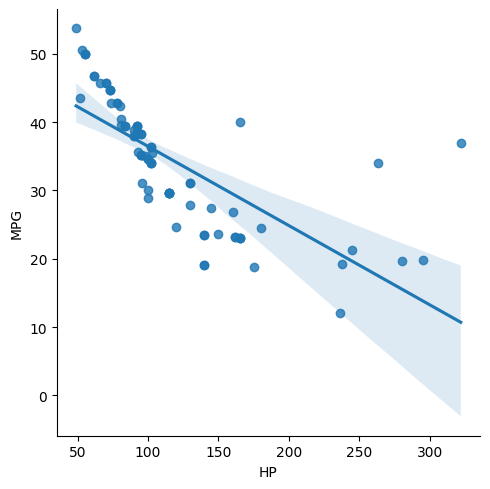

In [8]:
sns.lmplot(data = cars_data, x="HP", y="MPG",)

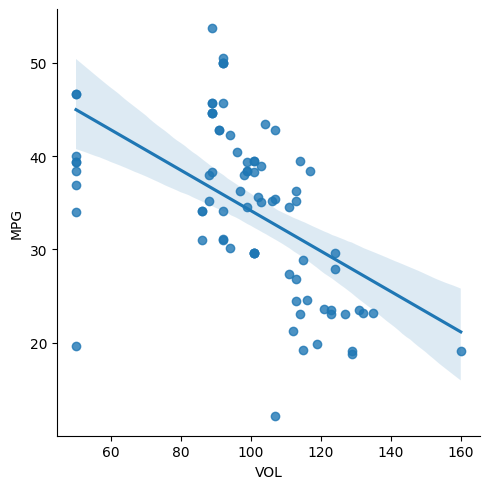

In [9]:
sns.lmplot(data = cars_data, x="VOL", y="MPG")

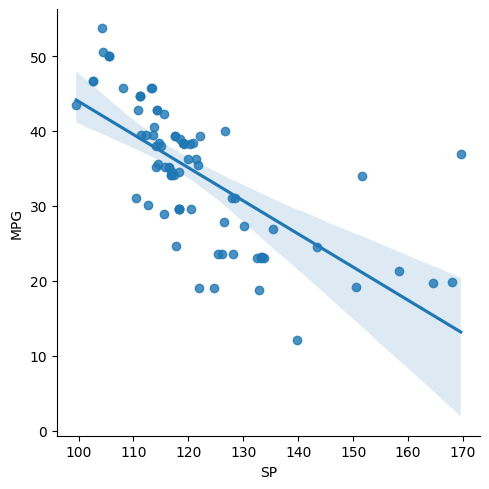

In [10]:
sns.lmplot(data = cars_data, x="SP", y="MPG",)

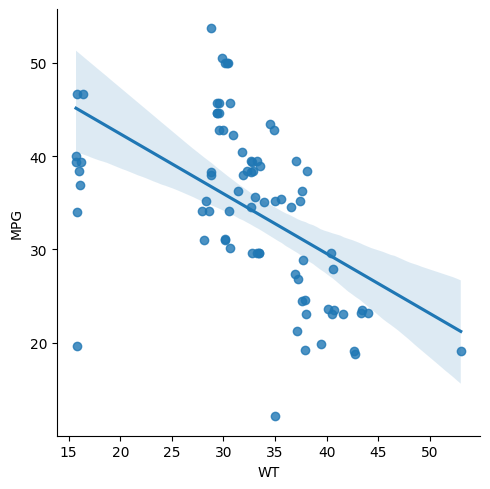

In [11]:
sns.lmplot(data = cars_data, x="WT", y="MPG",)

#### Test 1 Linearity Failed Because near the linaer line most the plot values should be aligned.

## Test 2: Data Level Normality Test - checks whether the data forms a bell curve use distplot

<Axes: ylabel='Density'>

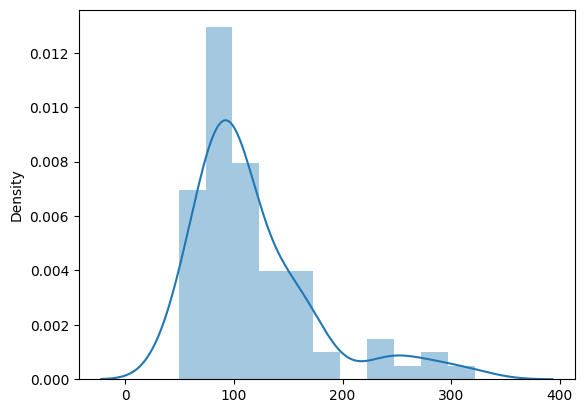

In [12]:
sns.distplot(x=cars_data["HP"])

<Axes: ylabel='Density'>

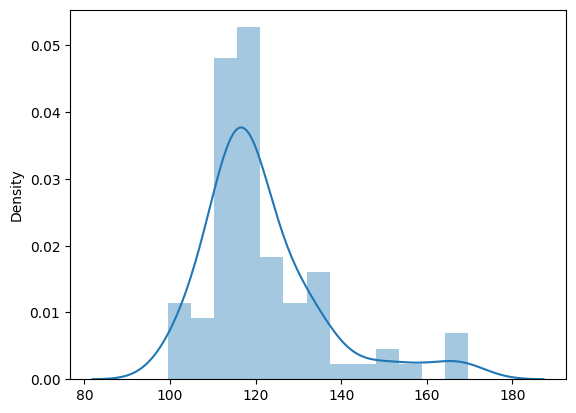

In [13]:
sns.distplot(x=cars_data["SP"])

<Axes: ylabel='Density'>

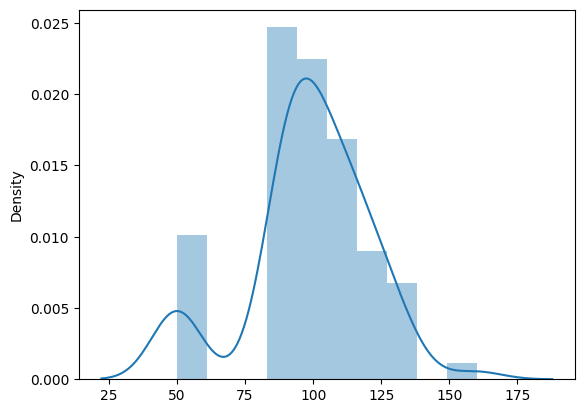

In [14]:
sns.distplot(x=cars_data["VOL"])

<Axes: ylabel='Density'>

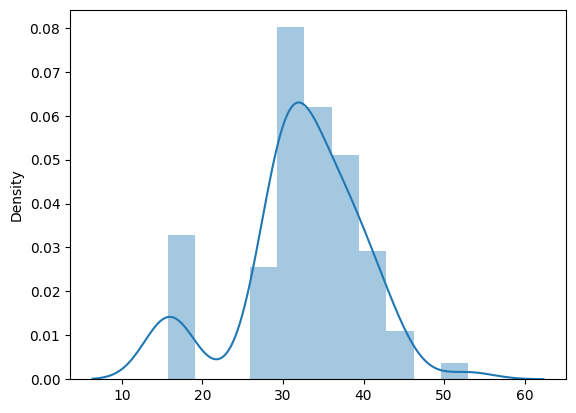

In [15]:
sns.distplot(x=cars_data["WT"])

### Test 2 Normality also Failed because no bell curve found.

### Test 3 - Multicollinearity Test can be tested before model building

In [16]:
corr_matrix = cars_data.corr()
corr_matrix

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


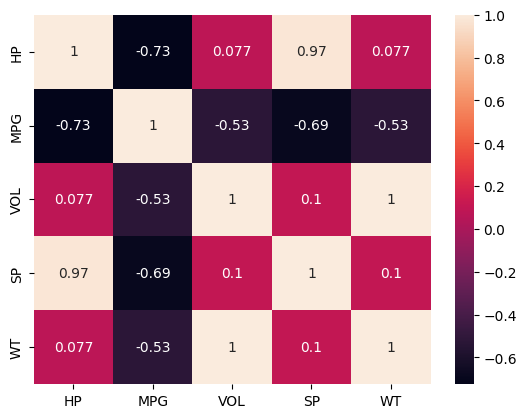

In [17]:
sns.heatmap(data = corr_matrix,annot=True)
plt.show()

### Test 3 - There is Multicollinearity in the Data

### Test 4 - AutoRegression Passed 
- If your data has no time component, you can usually say there is no autoregression problem.

## 4. Data Preparation

In [18]:
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


In [19]:
X = cars_data[["HP","VOL","SP","WT"]] # as input
X

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [68]:
y = cars_data["MPG"] # as output
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

### There is nothing to prepare because all features are numeric.

## 5. Model Building

This line creates an empty Linear Regression model object.

It does NOT train the model yet

It does NOT calculate coefficients yet

It does NOT make predictions yet

It simply initializes the model with default settings:

fit_intercept=True

copy_X=True

n_jobs=None

In [21]:
linear_model  = LinearRegression() # LinearRegression is a class a blueprint and we are access it's method by creating a instance/ object.

## 6. Model Training

linear_model.fit(X,y)
It teaches the model using your data
X = input features
y = target values

The model looks at the relationship between them and learns the best‑fitting straight line.
scikit‑learn:

Calculates the slope(s) → stored in linear_model.coef_

Calculates the intercept → stored in linear_model.intercept_

Minimizes the sum of squared errors (OLS)

Creates the regression line

Stores everything inside the object so you can use it later

After .fit(), the model becomes a trained model.

In [22]:
linear_model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
linear_model.intercept_

np.float64(30.67733585215165)

In [24]:
linear_model.coef_

array([-0.20544372, -0.33605084,  0.39562692,  0.40057409])

## 7.Model Testing

In [25]:
y_pred = linear_model.predict(X) # gives the predicted value of y(mpg) using input x
y_pred # but it doesn't match with the actual value of mpg

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

## 8. Model Evaluation

In [26]:
error = y - y_pred # finding residue (error) actualmpg - predicted Mpg
error

0     10.258747
1      7.624608
2      7.734060
3      3.157963
4      8.331584
        ...    
76    15.617904
77     1.298838
78     7.863547
79     7.517122
80    -3.458218
Name: MPG, Length: 81, dtype: float64

In [36]:
cars_data["error"] = error
cars_data

,HP,MPG,VOL,SP,WT,error
0,49,53.700681,89,104.185353,28.762059,10.258747
1,55,50.013401,92,105.461264,30.466833,7.624608
2,55,50.013401,92,105.461264,30.193597,7.734060
3,70,45.696322,92,113.461264,30.632114,3.157963
4,53,50.504232,92,104.461264,29.889149,8.331584
...,...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947,15.617904
77,238,19.197888,115,150.576579,37.923113,1.298838
78,263,34.000000,50,151.598513,15.769625,7.863547
79,295,19.833733,119,167.944460,39.423099,7.517122


In [38]:
cars_data["Y_Pred"] = y_pred

In [39]:
cars_data

,HP,MPG,VOL,SP,WT,error,Y_Pred
0,49,53.700681,89,104.185353,28.762059,10.258747,43.441935
1,55,50.013401,92,105.461264,30.466833,7.624608,42.388793
2,55,50.013401,92,105.461264,30.193597,7.734060,42.279341
3,70,45.696322,92,113.461264,30.632114,3.157963,42.538360
4,53,50.504232,92,104.461264,29.889149,8.331584,42.172648
...,...,...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947,15.617904,21.282096
77,238,19.197888,115,150.576579,37.923113,1.298838,17.899050
78,263,34.000000,50,151.598513,15.769625,7.863547,26.136453
79,295,19.833733,119,167.944460,39.423099,7.517122,12.316612


## Tests to be performed after Model building and training and testing and evaluation

#### 1. Linearity test test the linearity of predicated value against the error. It should be close to zero.

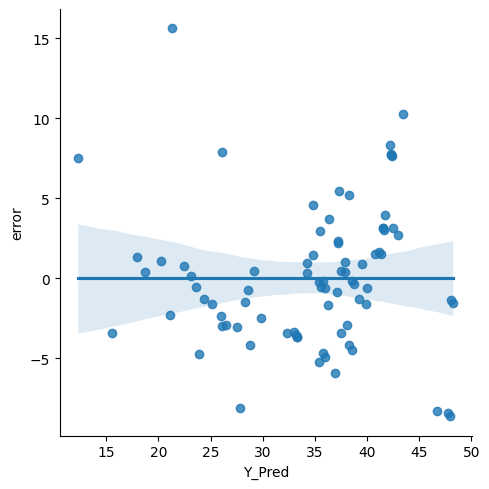

In [43]:
sns.lmplot(data=cars_data, x='Y_Pred', y='error' )

### Linearity test passed
The points don’t form a U‑shape, inverted U, or wave pattern.

They’re spread roughly evenly above and below the center line (around zero).

That randomness indicates the model captured the linear relationship between the predictors (hp, volume, speed, weight) and the target (mpg) correctly.

### 2. Normality Test 

<Axes: xlabel='MPG', ylabel='Count'>

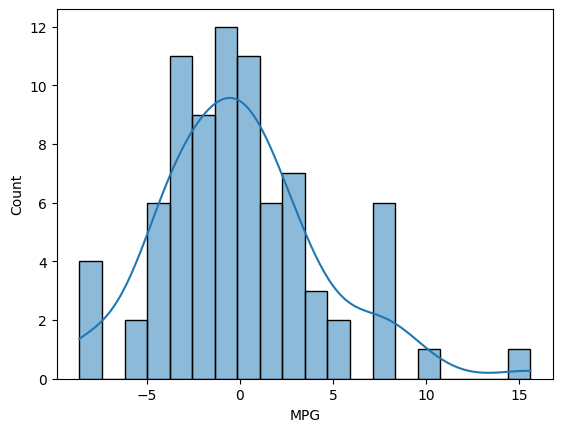

In [46]:
sns.histplot(error,bins=20, kde=True)

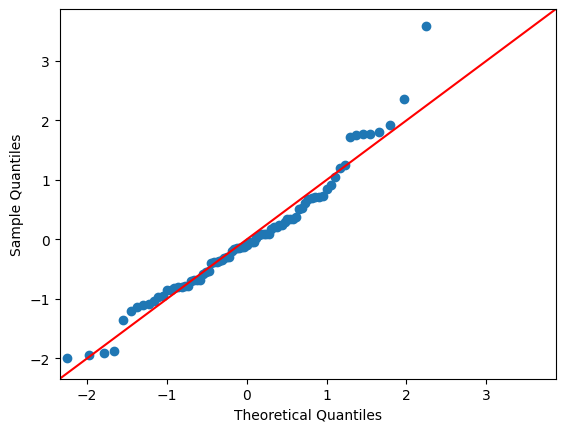

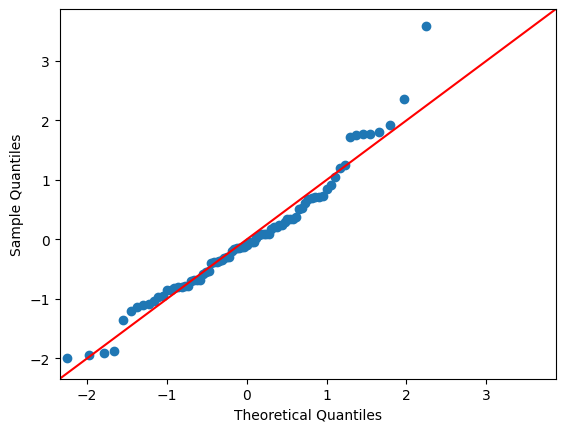

In [48]:
sm.qqplot(cars_data['error'], line='45', fit=True)


### Let's now perform Test 5: Homoscedasticity Test
Homoscedasticity means the residuals have constant variance across all levels of the predicted values (or predictors) — the spread of errors should look roughly the same whether your prediction is small or large.

You've actually already made this plot — it's the same Y_Pred vs error scatter you used for the linearity check. For homoscedasticity, instead of looking at the trend line, you look at the spread/width of the vertical scatter as you move left to right. Constant spread = homoscedastic.

why do we need to check our error againt the actual  inputvalue?  error is difference between actual output - predict_output?

 we check error against the actual input value because we want to know if our model's errors are unevenly sized depending on what kind of car (e.g., how powerful) we're predicting for.

 homoscedasticity isn't about how error is calculated — it's about whether the size of that error stays consistent across the range of your data, or whether it systematically grows/shrinks somewhere.

<Axes: xlabel='Y_Pred', ylabel='error'>

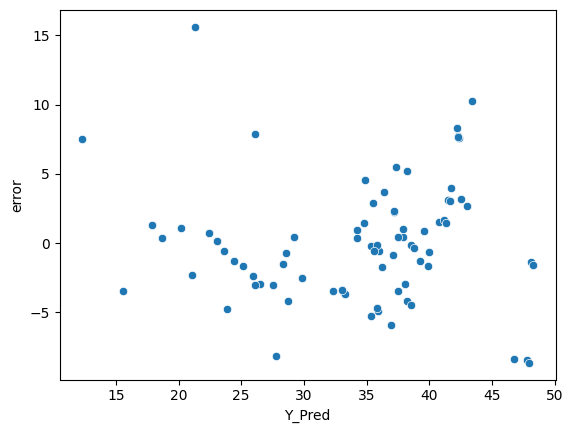

In [53]:
sns.scatterplot(data=cars_data, x = "Y_Pred", y = "error") #dots are not scattered so no homoscedasticity 

<Axes: xlabel='HP', ylabel='MPG'>

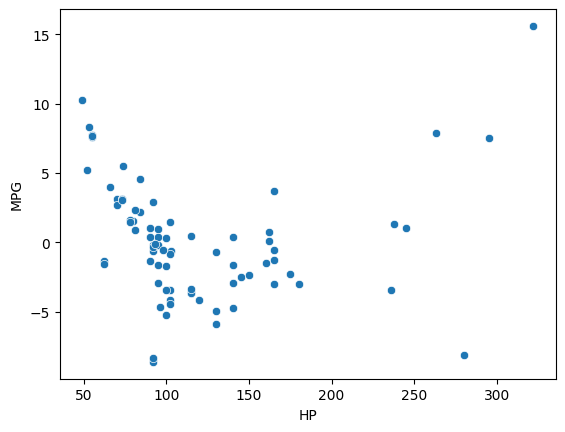

In [31]:
sns.scatterplot(data=cars_data, x = "HP", y = error)

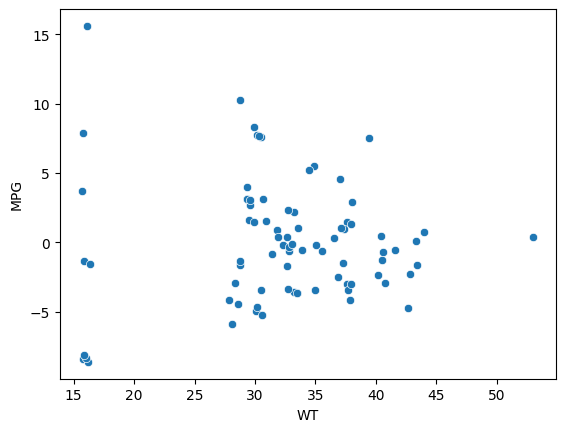

In [57]:
sns.scatterplot( data=cars_data,x = "WT", y = error)
plt.show()

### Test 5 Homoscedasticity Test also Failed

## Test 6: Zero Residual Mean Test

 one of the underlying assumptions is that the residuals have a mean of (approximately) zero overall.

 Why this test matters?
If the mean of residuals is NOT close to zero, it usually means:

You forgot the intercept (fit_intercept=False)

The model is misspecified

There is systematic bias (always over‑predicting or under‑predicting)

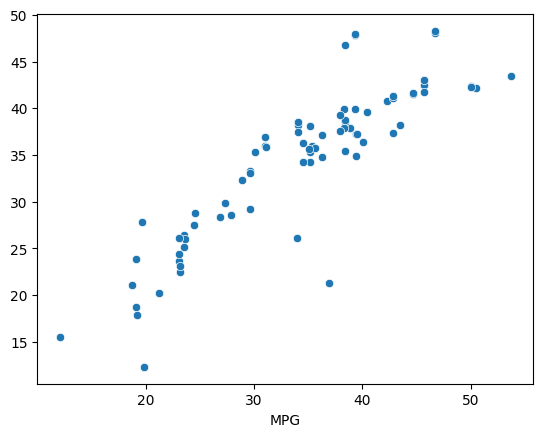

In [58]:
sns.scatterplot(x = cars_data["MPG"], y = y_pred)
plt.show()

In [54]:
print(cars_data['error'].mean())

3.50885301609926e-16


### Test 6: Zero Residual Mean Test is also Failed

## 9. Model Deployment

In [55]:
from pickle import dump

In [56]:
dump(obj = linear_model,file = open(file = "linear_intelligence_file.pkl", mode='wb'))

In [57]:
from pickle import load

In [58]:
linear_intel_pkl = load(file = open(file = "linear_intelligence_file.pkl", mode='rb'))
linear_intel_pkl

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [66]:
X = X.drop(columns=['const'], errors='ignore')


In [78]:
X = X[linear_intel_pkl.feature_names_in_]
X

,HP,VOL,SP,WT
0,49,89,104.185353,28.762059
1,55,92,105.461264,30.466833
2,55,92,105.461264,30.193597
3,70,92,113.461264,30.632114
4,53,92,104.461264,29.889149
...,...,...,...,...
76,322,50,169.598513,16.132947
77,238,115,150.576579,37.923113
78,263,50,151.598513,15.769625
79,295,119,167.944460,39.423099


In [79]:
linear_intel_pkl.predict(X)

array([43.44193477, 42.38879289, 42.27934147, 42.53835981, 42.17264802,
       43.02061916, 42.32536062, 48.07621852, 48.28120247, 40.79122814,
       41.52153227, 47.80956747, 39.95980269, 41.52757889, 41.76632332,
       41.6181448 , 41.15094046, 47.98605515, 41.30861046, 37.87127922,
       38.57706414, 37.35199705, 37.89770285, 39.5625144 , 39.93380662,
       46.73870908, 35.48165898, 38.78152504, 38.24861192, 36.00285298,
       34.84603989, 37.21630246, 37.13919796, 34.82541399, 37.22361389,
       37.53950097, 39.27144845, 38.24219888, 38.54286458, 35.9391722 ,
       34.2129755 , 35.36313259, 37.50473376, 38.07998482, 35.79651664,
       36.2613377 , 34.21826465, 35.59393404, 36.91805291, 33.31108154,
       33.21313413, 33.3023649 , 29.19864884, 27.52358579, 28.3207133 ,
       28.56722621, 35.81583602, 33.02108459, 35.37334971, 32.29909503,
       29.87685849, 28.76093817, 25.14188416, 26.47040896, 25.97651933,
       36.35652478, 26.0975912 , 23.6416178 , 24.39887199, 20.21

## THE END!!